In [1]:
import numpy as np
from pathlib import Path
import re
import pandas as pd
from IPython.display import display
import sys
import torch
import pickle
import matplotlib.pyplot as plt

In [2]:
# Path setting
PROJECT_ROOT = Path.cwd().parent
RESULTS_DIR = PROJECT_ROOT / "results"

TRANSFORMER_FILE = RESULTS_DIR / "transformer_results_comprehensive.txt"
ST_FILE = RESULTS_DIR / "results_metr_la_comprehensive.txt"
MULTIHOP_FILE = RESULTS_DIR / "results_multihop_comprehensive.txt"

In [3]:
def safe_float(value):
    match = re.search(r"-?\d+(\.\d+)?", str(value))
    return float(match.group()) if match else None


def parse_horizon_mape_details(file_path):
    rows = []

    if not file_path.exists():
        print(f"Missing file: {file_path}")
        return pd.DataFrame(columns=["Horizon", "Minutes", "MAPE"])

    in_mape_section = False

    with open(file_path, "r", encoding="utf-8") as f:
        for raw_line in f:
            line = raw_line.rstrip("\n")

            if "PER-HORIZON MAPE DETAILED BREAKDOWN" in line:
                in_mape_section = True
                continue

            if in_mape_section:
                stripped = line.strip()

                if not stripped:
                    continue
                if stripped.startswith("Horizon"):
                    continue
                if set(stripped) == {"-"}:
                    continue
                if stripped.startswith("MAPE TYPES"):
                    break
                if "SENSOR-LEVEL STATISTICS" in stripped:
                    break

                parts = stripped.split()

                try:
                    rows.append({
                        "Horizon": int(parts[0]),
                        "Minutes": int(parts[1]),
                        "MAPE": safe_float(parts[2]),
                    })
                except (ValueError, IndexError):
                    continue

    return pd.DataFrame(rows)


def parse_horizon_metrics(file_path):
    rows = []

    if not file_path.exists():
        print(f"Missing file: {file_path}")
        return pd.DataFrame(columns=["Horizon", "Minutes", "MAE", "RMSE", "MAPE"])

    in_horizon_section = False

    with open(file_path, "r", encoding="utf-8") as f:
        for raw_line in f:
            line = raw_line.rstrip("\n")

            if "PER-HORIZON PERFORMANCE BREAKDOWN" in line:
                in_horizon_section = True
                continue

            if in_horizon_section:
                stripped = line.strip()

                if not stripped:
                    continue
                if stripped.startswith("Horizon"):
                    continue
                if set(stripped) == {"-"}:
                    continue
                if "PER-HORIZON MAPE DETAILED BREAKDOWN" in stripped:
                    break
                if "COMPARISON WITH" in stripped:
                    break
                if "SENSOR-LEVEL STATISTICS" in stripped:
                    break

                parts = stripped.split()

                try:
                    row = {
                        "Horizon": int(parts[0]),
                        "Minutes": int(parts[1]),
                        "MAE": float(parts[2]),
                        "RMSE": float(parts[3]),
                        "MAPE": None,
                    }

                    if len(parts) >= 7:
                        row["MAPE"] = safe_float(parts[6])
                    elif len(parts) >= 5:
                        row["MAPE"] = safe_float(parts[4])

                    rows.append(row)

                except (ValueError, IndexError):
                    continue

    df = pd.DataFrame(rows)

    mape_df = parse_horizon_mape_details(file_path)
    if not df.empty and not mape_df.empty:
        df = df.drop(columns=["MAPE"], errors="ignore")
        df = df.merge(
            mape_df[["Minutes", "MAPE"]],
            on="Minutes",
            how="left"
        )

    return df


def get_metric_at_minutes(df, minutes, metric):
    row = df[df["Minutes"] == minutes]

    if row.empty:
        return None

    return float(row.iloc[0][metric])


# Build result dictionary
def load_results():
    transformer_df = parse_horizon_metrics(TRANSFORMER_FILE)
    st_df = parse_horizon_metrics(ST_FILE)
    multihop_df = parse_horizon_metrics(MULTIHOP_FILE)

    results = {
        "Transformer": {
            "15min": (
                get_metric_at_minutes(transformer_df, 15, "MAE"),
                get_metric_at_minutes(transformer_df, 15, "RMSE"),
                get_metric_at_minutes(transformer_df, 15, "MAPE"),
            ),
            "30min": (
                get_metric_at_minutes(transformer_df, 30, "MAE"),
                get_metric_at_minutes(transformer_df, 30, "RMSE"),
                get_metric_at_minutes(transformer_df, 30, "MAPE"),
            ),
            "60min": (
                get_metric_at_minutes(transformer_df, 60, "MAE"),
                get_metric_at_minutes(transformer_df, 60, "RMSE"),
                get_metric_at_minutes(transformer_df, 60, "MAPE"),
            ),
        },
        "ST-Transformer": {
            "15min": (
                get_metric_at_minutes(st_df, 15, "MAE"),
                get_metric_at_minutes(st_df, 15, "RMSE"),
                get_metric_at_minutes(st_df, 15, "MAPE"),
            ),
            "30min": (
                get_metric_at_minutes(st_df, 30, "MAE"),
                get_metric_at_minutes(st_df, 30, "RMSE"),
                get_metric_at_minutes(st_df, 30, "MAPE"),
            ),
            "60min": (
                get_metric_at_minutes(st_df, 60, "MAE"),
                get_metric_at_minutes(st_df, 60, "RMSE"),
                get_metric_at_minutes(st_df, 60, "MAPE"),
            ),
        },
        "Multi-Hop": {
            "15min": (
                get_metric_at_minutes(multihop_df, 15, "MAE"),
                get_metric_at_minutes(multihop_df, 15, "RMSE"),
                get_metric_at_minutes(multihop_df, 15, "MAPE"),
            ),
            "30min": (
                get_metric_at_minutes(multihop_df, 30, "MAE"),
                get_metric_at_minutes(multihop_df, 30, "RMSE"),
                get_metric_at_minutes(multihop_df, 30, "MAPE"),
            ),
            "60min": (
                get_metric_at_minutes(multihop_df, 60, "MAE"),
                get_metric_at_minutes(multihop_df, 60, "RMSE"),
                get_metric_at_minutes(multihop_df, 60, "MAPE"),
            ),
        },
        "MTESformer": {
            "15min": (2.73, 5.34, 7.10),
            "30min": (3.03, 6.22, 8.30),
            "60min": (3.37, 7.14, 9.62),
        },
    }

    return results


# Pretty table
def build_pretty_table(results):
    rows = []

    for model_name, metrics in results.items():
        rows.append([
            model_name,

            f"{metrics['15min'][0]:.2f}",
            f"{metrics['30min'][0]:.2f}",
            f"{metrics['60min'][0]:.2f}",

            f"{metrics['15min'][1]:.2f}",
            f"{metrics['30min'][1]:.2f}",
            f"{metrics['60min'][1]:.2f}",

            f"{metrics['15min'][2]:.2f}",
            f"{metrics['30min'][2]:.2f}",
            f"{metrics['60min'][2]:.2f}",
        ])

    columns = pd.MultiIndex.from_tuples([
        ("Model", ""),

        ("MAE", "15"),
        ("MAE", "30"),
        ("MAE", "60"),

        ("RMSE", "15"),
        ("RMSE", "30"),
        ("RMSE", "60"),

        ("MAPE (%)", "15"),
        ("MAPE (%)", "30"),
        ("MAPE (%)", "60"),
    ])

    return pd.DataFrame(rows, columns=columns)


def display_pretty_table(df):
    styled = (
        df.style
        .hide(axis="index")
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("border", "1px solid black"),
                    ("font-weight", "bold"),
                    ("background-color", "#f2f2f2"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "center"),
                    ("border", "1px solid black"),
                    ("padding", "6px"),
                ],
            },
            {
                "selector": "table",
                "props": [
                    ("border-collapse", "collapse"),
                    ("margin", "10px 0"),
                    ("font-size", "14px"),
                ],
            },
        ])
        .set_properties(
            subset=[("Model", "")],
            **{
                "text-align": "left",
                "font-weight": "bold",
                "min-width": "180px",
            }
        )
    )

    display(styled)


# Run
results = load_results()
pretty_df = build_pretty_table(results)

print("PERFORMANCE COMPARISON — METR-LA")
display_pretty_table(pretty_df)


# Improvement summary
st_60 = results["ST-Transformer"]["60min"][0]
mh_60 = results["Multi-Hop"]["60min"][0]
improvement = (st_60 - mh_60) / st_60 * 100

print(
    f"Multi-Hop vs ST-Transformer at 60min: "
    f"MAE {st_60:.2f} → {mh_60:.2f} "
    f"({improvement:+.1f}% improvement)"
)

PERFORMANCE COMPARISON — METR-LA


Multi-Hop vs ST-Transformer at 60min: MAE 4.72 → 4.66 (+1.2% improvement)


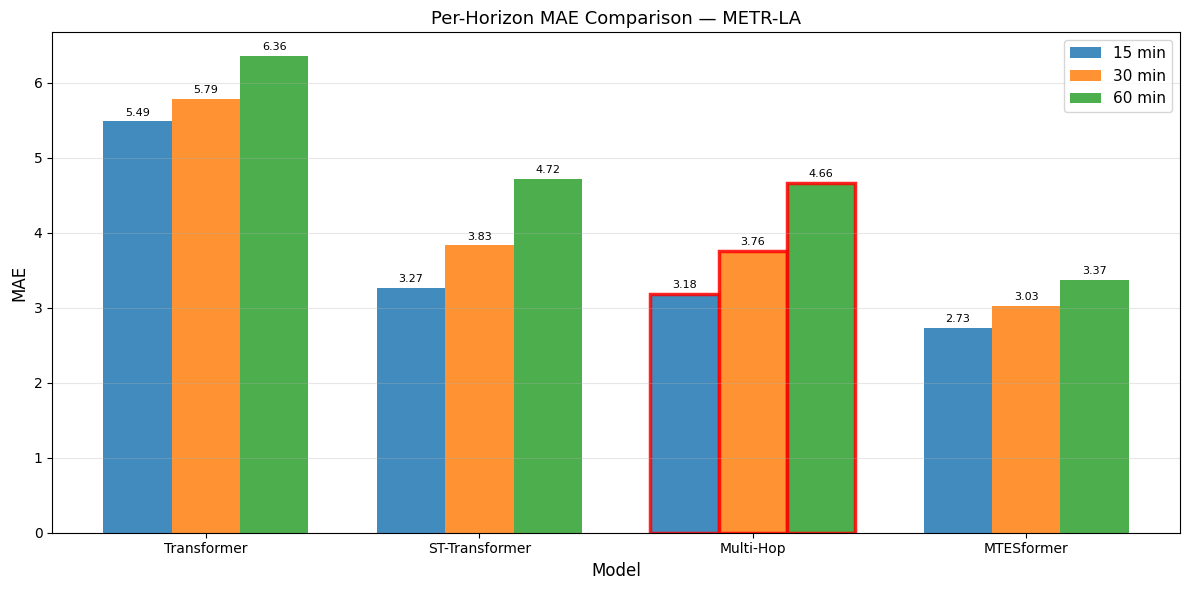

In [4]:
def plot_horizon_comparison_from_txt():
    models = ["Transformer", "ST-Transformer", "Multi-Hop", "MTESformer"]

    mae_15 = [results[m]["15min"][0] for m in models]
    mae_30 = [results[m]["30min"][0] for m in models]
    mae_60 = [results[m]["60min"][0] for m in models]

    display_names = [
        "Transformer",
        "ST-Transformer",
        "Multi-Hop",
        "MTESformer"
    ]

    x = np.arange(len(models))
    width = 0.25

    fig, ax = plt.subplots(figsize=(12, 6))

    bars1 = ax.bar(x - width, mae_15, width, label="15 min", alpha=0.85)
    bars2 = ax.bar(x, mae_30, width, label="30 min", alpha=0.85)
    bars3 = ax.bar(x + width, mae_60, width, label="60 min", alpha=0.85)

    highlight_idx = 2
    for bar_group in [bars1, bars2, bars3]:
        bar = bar_group[highlight_idx]
        bar.set_edgecolor("red")
        bar.set_linewidth(2.5)

    ax.set_xlabel("Model", fontsize=12)
    ax.set_ylabel("MAE", fontsize=12)
    ax.set_title("Per-Horizon MAE Comparison — METR-LA", fontsize=13)

    ax.set_xticks(x)
    ax.set_xticklabels(display_names, fontsize=10)

    ax.legend(fontsize=11)
    ax.grid(True, axis="y", alpha=0.3)

    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.05,
                f"{bar.get_height():.2f}",
                ha="center",
                va="bottom",
                fontsize=8
            )

    plt.tight_layout()

    # # Save as JPG
    # plt.savefig("horizon_comparison.jpg", dpi=300, bbox_inches="tight")
    
    plt.show()


plot_horizon_comparison_from_txt()

In [5]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
sys.path.append(str(PROJECT_ROOT / "models"))
from STTmodel import STTransformer
from ST_multihop import STTransformerMultiHop

# device
device = "cuda" if torch.cuda.is_available() else "cpu"

# load data
X_test = np.load(DATA_DIR / "metr_la_test_X.npy")
Y_test = np.load(DATA_DIR / "metr_la_test_Y.npy")

# load scaler
with open(DATA_DIR / "metr_la_scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

mean_arr = scaler.mean_
std_arr  = scaler.scale_

# load adjacency
with open(DATA_DIR / "metr_la_adj.pkl", "rb") as f:
    adj_obj = pickle.load(f)

adj = torch.tensor(
    adj_obj[2] if isinstance(adj_obj, list) else adj_obj,
    dtype=torch.float32
).to(device)

# load models
ck1 = torch.load(DATA_DIR / "best_metr_la.pt", map_location=device)
cfg1 = ck1["cfg"]

model_st = STTransformer(
    num_sensors=207,
    seq_len=cfg1["seq_len"],
    pred_len=cfg1["pred_len"],
    d_model=cfg1["d_model"],
    num_heads=cfg1["num_heads"],
    num_layers=cfg1["num_layers"],
    ff_dim=cfg1["ff_dim"],
    dropout=0.0
).to(device)

model_st.load_state_dict(ck1["model"])
model_st.eval()


ck2 = torch.load(DATA_DIR / "best_metr_la_multihop.pt", map_location=device)
cfg2 = ck2["cfg"]

model_mh = STTransformerMultiHop(
    num_sensors=207,
    seq_len=cfg2["seq_len"],
    pred_len=cfg2["pred_len"],
    d_model=cfg2["d_model"],
    num_heads=cfg2["num_heads"],
    num_layers=cfg2["num_layers"],
    ff_dim=cfg2["ff_dim"],
    dropout=0.0,
    adj=adj
).to(device)

model_mh.load_state_dict(ck2["model"])
model_mh.eval()

print("Models loaded successfully")

Models loaded successfully


C:\Users\USER\anaconda3\envs\DATA612_p\lib\site-packages\sklearn\base.py:347: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.3.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\USER\AppData\Local\Temp\ipykernel_23400\4182497444.py:25: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  adj = torch.tensor(


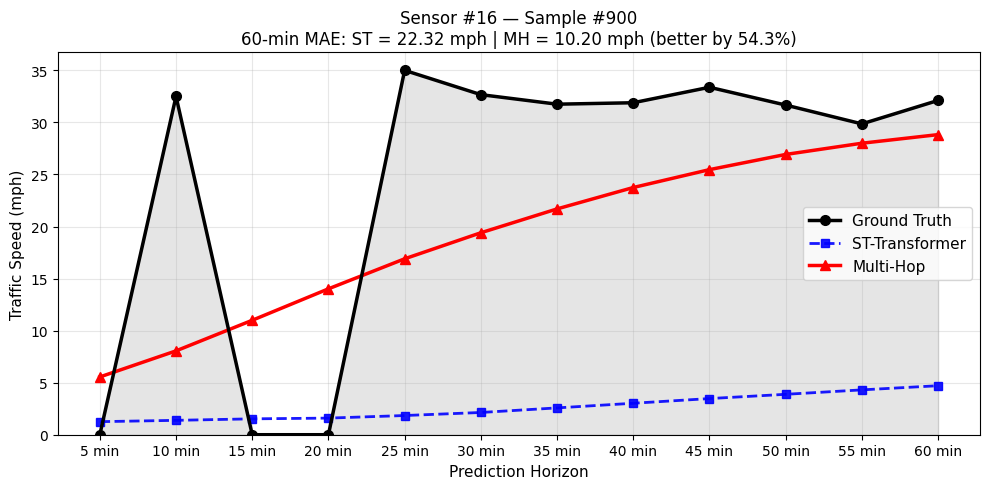

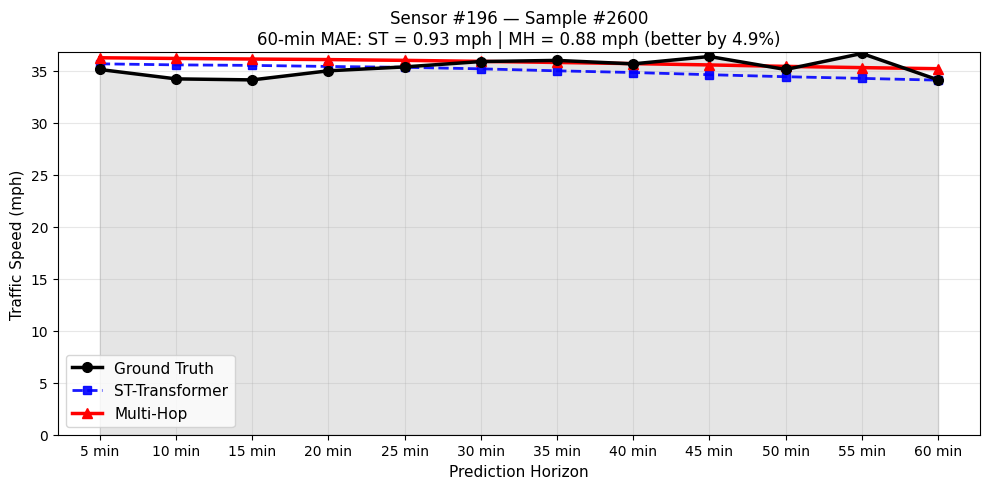

In [6]:
# Predict function
def predict_sample(sample_idx):
    model_st.eval()
    model_mh.eval()

    # Get one sample
    x = torch.tensor(
        X_test[sample_idx:sample_idx+1],
        dtype=torch.float32
    ).to(device)

    y_true = Y_test[sample_idx]

    # Model inference
    with torch.no_grad():
        pred_st = model_st(x).cpu().numpy()[0]
        pred_mh = model_mh(x).cpu().numpy()[0]

    # Inverse normalization
    def inverse_transform(data):
        return data * std_arr + mean_arr

    true_orig = inverse_transform(y_true)
    st_orig   = inverse_transform(pred_st)
    mh_orig   = inverse_transform(pred_mh)

    return true_orig, st_orig, mh_orig


# Plot function
def try_sample(sample_idx, sensor_id=87, save_path=None):

    true_orig, st_orig, mh_orig = predict_sample(sample_idx)

    time_steps = [f"{(i+1)*5} min" for i in range(12)]

    true_y = true_orig[:, sensor_id]
    st_y   = st_orig[:, sensor_id]
    mh_y   = mh_orig[:, sensor_id]

    # Compute MAE
    mae_st = np.mean(np.abs(st_y - true_y))
    mae_mh = np.mean(np.abs(mh_y - true_y))

    improvement = (mae_st - mae_mh) / mae_st * 100
    status = "better" if improvement > 0 else "worse"

    # Plot
    fig, ax = plt.subplots(figsize=(10, 5))

    # Ground truth area
    ax.fill_between(range(12), true_y, alpha=0.1, color='black')

    ax.plot(
        time_steps, true_y,
        'k-o',
        linewidth=2.5,
        markersize=7,
        label='Ground Truth',
        zorder=4
    )

    ax.plot(
        time_steps, st_y,
        'b--s',
        linewidth=2,
        markersize=6,
        label='ST-Transformer',
        alpha=0.9
    )

    ax.plot(
        time_steps, mh_y,
        'r-^',
        linewidth=2.5,
        markersize=7,
        label='Multi-Hop',
        zorder=3
    )

    ax.set_title(
        f"Sensor #{sensor_id} — Sample #{sample_idx}\n"
        f"60-min MAE: ST = {mae_st:.2f} mph | MH = {mae_mh:.2f} mph "
        f"({status} by {abs(improvement):.1f}%)",
        fontsize=12
    )

    ax.set_xlabel("Prediction Horizon", fontsize=11)
    ax.set_ylabel("Traffic Speed (mph)", fontsize=11)

    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11)

    plt.tight_layout()

    # # Save figure as JPG
    # if save_path is not None:
    #     plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()
    plt.close(fig)


# Run examples and save JPG files
try_sample(
    sample_idx=900,
    sensor_id=16,
    save_path="sample_900_sensor_16.jpg"
)

try_sample(
    sample_idx=2600,
    sensor_id=196,
    save_path="sample_2600_sensor_196.jpg"
)